In [1]:
import gzip
import io
import json
import math
import os
import random
import re
import sys
import time
import unicodedata
from collections import Counter, defaultdict

import numpy as np
import scipy.sparse as sp

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

# where Assignment 1 wrote its splits
ASSIGNMENT1_DATA = os.path.join("..", "Assignment - 1", "data")

print("python:", sys.version.split()[0], "| numpy:", np.__version__)

python: 3.11.9 | numpy: 2.4.6


In [2]:
CONFIG = {
    "sentences_per_language": 1000,
    "max_lines_to_scan": 40000,
    "min_chars": 20,
    "max_chars": 300,
    "min_words": 4,
    "split_ratio": (0.8, 0.1, 0.1),

    "word_ngrams": (1, 2),
    "char_ngrams": (2, 3, 4),
    "min_df": 3,
    "max_features": {"w1": 100000, "w2": 100000, "c2": 50000, "c3": 150000, "c4": 250000},

    "lr": 0.05,
    "epochs": 40,
    "batch_size": 2048,
    "l2": 1e-6,
    "patience": 6,
}
CONFIG

{'sentences_per_language': 1000,
 'max_lines_to_scan': 40000,
 'min_chars': 20,
 'max_chars': 300,
 'min_words': 4,
 'split_ratio': (0.8, 0.1, 0.1),
 'word_ngrams': (1, 2),
 'char_ngrams': (2, 3, 4),
 'min_df': 3,
 'max_features': {'w1': 100000,
  'w2': 100000,
  'c2': 50000,
  'c3': 150000,
  'c4': 250000},
 'lr': 0.05,
 'epochs': 40,
 'batch_size': 2048,
 'l2': 1e-06,
 'patience': 6}

In [3]:
# ------------------------------------------------------------------ tokenization
DANDA = "।"
DOUBLE_DANDA = "॥"
ARABIC_FULL_STOP = "۔"
ARABIC_QUESTION = "؟"
ELLIPSIS = "…"
IDEOGRAPHIC_STOP = "。"
HARD_STOPS = (DANDA + DOUBLE_DANDA + ARABIC_FULL_STOP + ARABIC_QUESTION
              + ELLIPSIS + IDEOGRAPHIC_STOP + "!?")

_HARD_SPLIT = re.compile(r"(?<=[" + re.escape(HARD_STOPS) + r"])\s+|\n+")
_DOT_SPLIT = re.compile(r"(?<![A-Z]\.)(?<!\d\.)(?<=\.)\s+(?!\d)")
_WS = re.compile(r"\s+")
_URL = re.compile(r"https?://\S+|www\.\S+|\S+@\S+\.\S+")

_MARK_CATEGORIES = {"Mn", "Mc", "Me"}
_CHAR_CLASS_CACHE = {}


def sentence_tokenize(paragraph):
    paragraph = _URL.sub(" ", paragraph)
    sentences = []
    for chunk in _HARD_SPLIT.split(paragraph):
        if not chunk:
            continue
        for piece in _DOT_SPLIT.split(chunk):
            piece = _WS.sub(" ", piece).strip()
            if piece:
                sentences.append(piece)
    return sentences


def is_word_char(ch):
    cached = _CHAR_CLASS_CACHE.get(ch)
    if cached is None:
        cached = ch.isalnum() or unicodedata.category(ch) in _MARK_CATEGORIES
        _CHAR_CLASS_CACHE[ch] = cached
    return cached


def word_tokenize(text):
    tokens, buf = [], []
    for ch in text:
        if is_word_char(ch):
            buf.append(ch)
        elif buf:
            tokens.append("".join(buf))
            buf = []
    if buf:
        tokens.append("".join(buf))
    return tokens


def is_letterish(ch):
    cat = unicodedata.category(ch)
    return cat[0] == "L" or cat in _MARK_CATEGORIES


def acceptable_sentence(sentence, cfg=CONFIG):
    n = len(sentence)
    if n < cfg["min_chars"] or n > cfg["max_chars"]:
        return False
    words = word_tokenize(sentence)
    if len(words) < cfg["min_words"]:
        return False
    return sum(1 for ch in sentence if is_letterish(ch)) / n >= 0.6


# ------------------------------------------------------------------ features
def extract_features(text, word_ngrams=CONFIG["word_ngrams"], char_ngrams=CONFIG["char_ngrams"]):
    feats = Counter()
    words = word_tokenize(text.lower())
    lo, hi = word_ngrams
    for n in range(lo, hi + 1):
        prefix = "w%d:" % n
        if n == 1:
            for w in words:
                feats[prefix + w] += 1
        else:
            for i in range(len(words) - n + 1):
                feats[prefix + " ".join(words[i:i + n])] += 1
    for word in words:
        padded = " " + word + " "
        L = len(padded)
        for n in char_ngrams:
            prefix = "c%d:" % n
            if L < n:
                continue
            for i in range(L - n + 1):
                feats[prefix + padded[i:i + n]] += 1
    return feats


# ------------------------------------------------------------------ metrics
def confusion_matrix(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    np.add.at(cm, (np.asarray(y_true), np.asarray(y_pred)), 1)
    return cm


def prf_per_class(y_true, y_pred, n_classes):
    cm = confusion_matrix(y_true, y_pred, n_classes)
    tp = np.diag(cm).astype(np.float64)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) > 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp), where=(tp + fn) > 0)
    denom = precision + recall
    f1 = np.divide(2 * precision * recall, denom, out=np.zeros_like(tp), where=denom > 0)
    return precision, recall, f1, cm.sum(axis=1)


def macro_f1(y_true, y_pred, n_classes):
    return float(prf_per_class(y_true, y_pred, n_classes)[2].mean())


def accuracy(y_true, y_pred):
    return float((np.asarray(y_true) == np.asarray(y_pred)).mean())


assert abs(macro_f1(np.array([0, 0, 1, 1, 2]), np.array([0, 1, 1, 1, 2]), 3) - 0.822222) < 1e-5
print("carried-over metric implementation verified")

carried-over metric implementation verified


In [4]:
def load_splits(directory):
    out = {}
    for name in ("train", "val", "test"):
        path = os.path.join(directory, name + ".tsv")
        if not os.path.exists(path):
            return None
        texts, labels = [], []
        with io.open(path, encoding="utf-8") as f:
            header = f.readline()
            for line in f:
                line = line.rstrip("\n")
                if not line:
                    continue
                label, _, text = line.partition("\t")
                texts.append(text)
                labels.append(label)
        out[name] = (texts, labels)
    return out


splits = load_splits(ASSIGNMENT1_DATA) or load_splits(DATA_DIR)
if splits is not None:
    print("loaded the Assignment 1 splits from disk")
else:
    print("Assignment 1 splits not found - rebuilding the dataset from IndicCorp v2")

loaded the Assignment 1 splits from disk


In [5]:
if splits is None:
    from huggingface_hub import HfApi, hf_hub_url
    import requests

    try:
        from huggingface_hub import get_token
    except ImportError:
        from huggingface_hub import HfFolder

        def get_token():
            return HfFolder.get_token()

    REPO_ID = "ai4bharat/IndicCorpV2"
    _FILE_RE = re.compile(r"(?:^|/)([A-Za-z]{2,4}(?:[_-][A-Za-z]{4})?)\.txt(\.gz)?$")

    def discover_language_files(repo_id=REPO_ID):
        found = {}
        for path in HfApi().list_repo_files(repo_id, repo_type="dataset"):
            m = _FILE_RE.search(path)
            if m and (m.group(1) not in found or len(path) < len(found[m.group(1)])):
                found[m.group(1)] = path
        return dict(sorted(found.items()))

    def stream_lines(repo_path, max_lines, repo_id=REPO_ID, timeout=60):
        url = hf_hub_url(repo_id, repo_path, repo_type="dataset")
        token = get_token()
        headers = {"Authorization": "Bearer " + token} if token else {}
        with requests.get(url, headers=headers, stream=True, timeout=timeout) as resp:
            resp.raise_for_status()
            raw = gzip.GzipFile(fileobj=resp.raw) if repo_path.endswith(".gz") else resp.raw
            for i, line in enumerate(io.TextIOWrapper(raw, encoding="utf-8", errors="ignore")):
                if i >= max_lines:
                    break
                yield line

    corpus = {}
    for label, path in discover_language_files().items():
        seen, kept = set(), []
        try:
            for line in stream_lines(path, CONFIG["max_lines_to_scan"]):
                for s in sentence_tokenize(line):
                    if s not in seen and acceptable_sentence(s):
                        seen.add(s)
                        kept.append(s)
                        if len(kept) >= CONFIG["sentences_per_language"]:
                            raise StopIteration
        except StopIteration:
            pass
        except Exception as exc:
            print("  !!", label, type(exc).__name__, exc)
        print("  %-10s %5d sentences" % (label, len(kept)))
        if len(kept) >= CONFIG["sentences_per_language"]:
            corpus[label] = kept

    rng = random.Random(SEED)
    train, val, test = [], [], []
    for label in sorted(corpus):
        sents = list(corpus[label])
        rng.shuffle(sents)
        n = len(sents)
        a = int(round(CONFIG["split_ratio"][0] * n))
        b = a + int(round(CONFIG["split_ratio"][1] * n))
        train += [(s, label) for s in sents[:a]]
        val += [(s, label) for s in sents[a:b]]
        test += [(s, label) for s in sents[b:]]
    for part in (train, val, test):
        rng.shuffle(part)

    splits = {}
    for name, part in (("train", train), ("val", val), ("test", test)):
        texts, labels = zip(*part)
        splits[name] = (list(texts), list(labels))
        with io.open(os.path.join(DATA_DIR, name + ".tsv"), "w", encoding="utf-8",
                     newline="\n") as f:
            f.write("label\ttext\n")
            for t, l in zip(texts, labels):
                f.write(l + "\t" + t + "\n")
    print("rebuilt and saved the splits under", DATA_DIR)

In [6]:
X_train_txt, y_train_lab = splits["train"]
X_val_txt, y_val_lab = splits["val"]
X_test_txt, y_test_lab = splits["test"]

LABELS = sorted(set(y_train_lab))
LABEL2ID = {lab: i for i, lab in enumerate(LABELS)}
y_train = np.array([LABEL2ID[l] for l in y_train_lab], dtype=np.int32)
y_val = np.array([LABEL2ID[l] for l in y_val_lab], dtype=np.int32)
y_test = np.array([LABEL2ID[l] for l in y_test_lab], dtype=np.int32)

print("%d languages" % len(LABELS))
print("train %6d   val %5d   test %5d" % (len(X_train_txt), len(X_val_txt), len(X_test_txt)))
print(LABELS)

23 languages
train  18400   val  2300   test  2300
['as', 'bd', 'bn', 'dg', 'en', 'gom', 'gu', 'kha', 'kn', 'ks', 'mai', 'ml', 'mni', 'mr', 'ne', 'or', 'pa', 'sa', 'sat', 'sd', 'ta', 'te', 'ur']


In [7]:
def l2_normalize(X):
    X = X.tocsr(copy=True)
    norms = np.sqrt(np.asarray(X.multiply(X).sum(axis=1))).ravel()
    norms[norms == 0] = 1.0
    inv = np.repeat(1.0 / norms, np.diff(X.indptr))
    X.data = (X.data * inv).astype(X.dtype)
    return X


class TfIdfVectorizer:
    """From-scratch TF-IDF vectorizer, parameterised over the TF and IDF normalizations."""

    TF_SCHEMES = ("raw", "len", "max")
    IDF_SCHEMES = ("standard", "maxdf")

    def __init__(self, word_ngrams=CONFIG["word_ngrams"], char_ngrams=CONFIG["char_ngrams"],
                 min_df=CONFIG["min_df"], max_features=None,
                 tf_scheme="raw", idf_scheme="standard", norm=None):
        if tf_scheme not in self.TF_SCHEMES:
            raise ValueError("unknown tf_scheme %r" % (tf_scheme,))
        if idf_scheme not in self.IDF_SCHEMES:
            raise ValueError("unknown idf_scheme %r" % (idf_scheme,))
        self.word_ngrams = word_ngrams
        self.char_ngrams = char_ngrams
        self.min_df = min_df
        self.max_features = max_features if max_features is not None else CONFIG["max_features"]
        self.tf_scheme = tf_scheme
        self.idf_scheme = idf_scheme
        self.norm = norm
        self.vocabulary_ = None
        self.idf_ = None

    def _count_docs(self, docs):
        return [extract_features(d, self.word_ngrams, self.char_ngrams) for d in docs]

    # -------------------------------------------------------------- IDF
    def fit(self, docs, counted=None, verbose=True):
        counted = counted if counted is not None else self._count_docs(docs)
        n_docs = len(counted)

        df = Counter()
        for c in counted:
            df.update(c.keys())

        by_family = defaultdict(list)
        for feat, d in df.items():
            if d >= self.min_df:
                by_family[feat[:2]].append((d, feat))

        vocabulary, kept_df = {}, []
        for family in sorted(by_family):
            items = by_family[family]
            cap = self.max_features.get(family)
            if cap is not None and len(items) > cap:
                items.sort(key=lambda x: (-x[0], x[1]))
                items = items[:cap]
            for d, feat in sorted(items, key=lambda x: x[1]):
                vocabulary[feat] = len(vocabulary)
                kept_df.append(d)

        self.vocabulary_ = vocabulary
        self.df_ = np.asarray(kept_df, dtype=np.float64)
        self.n_docs_ = n_docs
        self.max_df_ = float(self.df_.max())

        if self.idf_scheme == "standard":
            # unnormalized: log(N / df(t))
            self.idf_ = np.log(n_docs / self.df_)
        else:
            # normalized by the document frequency of the most frequent word across sentences
            self.idf_ = np.log(self.max_df_ / self.df_)
        self.idf_ = np.maximum(self.idf_, 0.0)

        if verbose:
            print("  vocab {:,}  |  max df {:,}  |  idf range [{:.3f}, {:.3f}]".format(
                len(vocabulary), int(self.max_df_), self.idf_.min(), self.idf_.max()))
        return self

    # -------------------------------------------------------------- TF
    def _tf_scale(self, counter):
        """Per-document multiplicative factor implementing the TF normalization."""
        if self.tf_scheme == "raw":
            return 1.0
        if self.tf_scheme == "len":
            total = sum(v for k, v in counter.items() if k.startswith("w1:"))
            return 1.0 / total if total else 1.0
        top = max((v for k, v in counter.items() if k.startswith("w1:")), default=0)
        return 1.0 / top if top else 1.0

    def transform(self, docs, counted=None, dtype=np.float32):
        if self.vocabulary_ is None:
            raise RuntimeError("call fit() first")
        counted = counted if counted is not None else self._count_docs(docs)
        vocab, idf = self.vocabulary_, self.idf_
        indptr, indices, data = [0], [], []
        for counter in counted:
            scale = self._tf_scale(counter)
            for feat, count in counter.items():
                j = vocab.get(feat)
                if j is None:
                    continue
                indices.append(j)
                data.append(count * scale * idf[j])
            indptr.append(len(indices))
        X = sp.csr_matrix(
            (np.asarray(data, dtype=dtype),
             np.asarray(indices, dtype=np.int32),
             np.asarray(indptr, dtype=np.int64)),
            shape=(len(counted), len(vocab)))
        X.sum_duplicates()
        return l2_normalize(X) if self.norm == "l2" else X

    def fit_transform(self, docs, counted=None, verbose=True):
        counted = counted if counted is not None else self._count_docs(docs)
        self.fit(docs, counted=counted, verbose=verbose)
        return self.transform(docs, counted=counted)

In [8]:
class SoftmaxRegression:
    def __init__(self, n_features, n_classes, lr=CONFIG["lr"], l2=CONFIG["l2"],
                 batch_size=CONFIG["batch_size"], epochs=CONFIG["epochs"],
                 patience=CONFIG["patience"], seed=SEED):
        self.n_features, self.n_classes = n_features, n_classes
        self.lr, self.l2 = lr, l2
        self.batch_size, self.epochs, self.patience = batch_size, epochs, patience
        self.W = np.zeros((n_features, n_classes), dtype=np.float32)
        self.b = np.zeros(n_classes, dtype=np.float32)
        self.rng = np.random.RandomState(seed)
        self.history_ = []

    @staticmethod
    def _softmax(scores):
        scores = scores - scores.max(axis=1, keepdims=True)
        np.exp(scores, out=scores)
        scores /= scores.sum(axis=1, keepdims=True)
        return scores

    def decision_function(self, X):
        return np.asarray(X @ self.W) + self.b

    def predict_proba(self, X):
        return self._softmax(self.decision_function(X).astype(np.float64))

    def predict(self, X):
        return np.argmax(self.decision_function(X), axis=1)

    def loss(self, X, y):
        P = self.predict_proba(X)
        nll = -np.log(np.clip(P[np.arange(len(y)), y], 1e-12, None)).mean()
        return float(nll + 0.5 * self.l2 * float((self.W ** 2).sum()))

    def fit(self, X, y, X_val=None, y_val=None, verbose=True):
        n = X.shape[0]
        mW = np.zeros_like(self.W); vW = np.zeros_like(self.W)
        mb = np.zeros_like(self.b); vb = np.zeros_like(self.b)
        beta1, beta2, eps = 0.9, 0.999, 1e-8
        step = 0
        best_score, best_state, stale = -1.0, None, 0
        for epoch in range(1, self.epochs + 1):
            order = self.rng.permutation(n)
            t0 = time.time()
            for start in range(0, n, self.batch_size):
                idx = order[start:start + self.batch_size]
                Xb, yb = X[idx], y[idx]
                B = Xb.shape[0]
                P = self._softmax(self.decision_function(Xb).astype(np.float64))
                P[np.arange(B), yb] -= 1.0
                P /= B
                gW = np.asarray(Xb.T @ P, dtype=np.float32) + self.l2 * self.W
                gb = P.sum(axis=0).astype(np.float32)
                step += 1
                bc1, bc2 = 1.0 - beta1 ** step, 1.0 - beta2 ** step
                mW *= beta1; mW += (1 - beta1) * gW
                vW *= beta2; vW += (1 - beta2) * (gW * gW)
                self.W -= self.lr * (mW / bc1) / (np.sqrt(vW / bc2) + eps)
                mb *= beta1; mb += (1 - beta1) * gb
                vb *= beta2; vb += (1 - beta2) * (gb * gb)
                self.b -= self.lr * (mb / bc1) / (np.sqrt(vb / bc2) + eps)
            record = {"epoch": epoch, "train_loss": self.loss(X, y), "sec": time.time() - t0}
            if X_val is not None:
                pred = self.predict(X_val)
                record["val_macro_f1"] = macro_f1(y_val, pred, self.n_classes)
                record["val_acc"] = accuracy(y_val, pred)
            self.history_.append(record)
            if verbose:
                msg = "epoch %3d  loss %.4f" % (epoch, record["train_loss"])
                if X_val is not None:
                    msg += "  val_macroF1 %.4f" % record["val_macro_f1"]
                print(msg)
            if X_val is not None:
                if record["val_macro_f1"] > best_score + 1e-5:
                    best_score, stale = record["val_macro_f1"], 0
                    best_state = (self.W.copy(), self.b.copy())
                else:
                    stale += 1
                    if stale >= self.patience:
                        break
        if best_state is not None:
            self.W, self.b = best_state
        return self

In [9]:
t0 = time.time()
counts_train = [extract_features(t) for t in X_train_txt]
counts_val = [extract_features(t) for t in X_val_txt]
counts_test = [extract_features(t) for t in X_test_txt]
print("n-gram counting done in %.1fs (shared by all six runs)" % (time.time() - t0))

n-gram counting done in 3.7s (shared by all six runs)


In [10]:
TF_SCHEMES = [
    ("raw", "TF unnormalized  c(t,d)"),
    ("len", "TF / total words in sentence"),
    ("max", "TF / max word freq in sentence"),
]
IDF_SCHEMES = [
    ("standard", "IDF unnormalized  log(N/df)"),
    ("maxdf", "IDF / max df across sentences"),
]

results = []
for tf_scheme, tf_desc in TF_SCHEMES:
    for idf_scheme, idf_desc in IDF_SCHEMES:
        name = "tf=%s + idf=%s" % (tf_scheme, idf_scheme)
        print("\n" + "=" * 72)
        print("combination %d/6:  %s" % (len(results) + 1, name))
        print("  %s | %s" % (tf_desc, idf_desc))
        print("=" * 72)

        t0 = time.time()
        vec = TfIdfVectorizer(tf_scheme=tf_scheme, idf_scheme=idf_scheme, norm=None)
        Xtr = vec.fit_transform(X_train_txt, counted=counts_train)
        Xva = vec.transform(X_val_txt, counted=counts_val)
        Xte = vec.transform(X_test_txt, counted=counts_test)
        vec_time = time.time() - t0

        # a quick look at what the weighting did to the value distribution
        print("  nonzero value: mean %.5f  max %.5f  |  row L2 norm: mean %.4f" % (
            float(Xtr.data.mean()), float(Xtr.data.max()),
            float(np.sqrt(np.asarray(Xtr.multiply(Xtr).sum(axis=1))).mean())))

        t0 = time.time()
        clf = SoftmaxRegression(Xtr.shape[1], len(LABELS))
        clf.fit(Xtr, y_train, Xva, y_val, verbose=False)
        fit_time = time.time() - t0

        val_pred, test_pred = clf.predict(Xva), clf.predict(Xte)
        row = {
            "tf": tf_scheme,
            "idf": idf_scheme,
            "name": name,
            "n_features": Xtr.shape[1],
            "epochs_run": len(clf.history_),
            "val_macro_f1": macro_f1(y_val, val_pred, len(LABELS)),
            "val_acc": accuracy(y_val, val_pred),
            "test_macro_f1": macro_f1(y_test, test_pred, len(LABELS)),
            "test_acc": accuracy(y_test, test_pred),
            "vec_sec": vec_time,
            "fit_sec": fit_time,
            "per_class_f1": prf_per_class(y_test, test_pred, len(LABELS))[2],
        }
        results.append(row)
        print("  -> val macro-F1 %.4f | TEST macro-F1 %.4f | test acc %.4f  (%d epochs, %.0fs)" % (
            row["val_macro_f1"], row["test_macro_f1"], row["test_acc"],
            row["epochs_run"], vec_time + fit_time))

print("\nall six combinations done")


combination 1/6:  tf=raw + idf=standard
  TF unnormalized  c(t,d) | IDF unnormalized  log(N/df)
  vocab 167,934  |  max df 3,981  |  idf range [1.531, 8.721]
  nonzero value: mean 6.49522  max 99.35840  |  row L2 norm: mean 89.8830
  -> val macro-F1 0.9314 | TEST macro-F1 0.9358 | test acc 0.9361  (14 epochs, 21s)

combination 2/6:  tf=raw + idf=maxdf
  TF unnormalized  c(t,d) | IDF / max df across sentences
  vocab 167,934  |  max df 3,981  |  idf range [0.000, 7.191]
  nonzero value: mean 4.62429  max 65.85374  |  row L2 norm: mean 65.4725
  -> val macro-F1 0.9335 | TEST macro-F1 0.9353 | test acc 0.9352  (9 epochs, 13s)

combination 3/6:  tf=len + idf=standard
  TF / total words in sentence | IDF unnormalized  log(N/df)
  vocab 167,934  |  max df 3,981  |  idf range [1.531, 8.721]
  nonzero value: mean 0.44947  max 7.32784  |  row L2 norm: mean 7.1364
  -> val macro-F1 0.9421 | TEST macro-F1 0.9418 | test acc 0.9417  (22 epochs, 31s)

combination 4/6:  tf=len + idf=maxdf
  TF / tot

In [11]:
mats = {}
for tf_scheme, _ in TF_SCHEMES:
    v = TfIdfVectorizer(tf_scheme=tf_scheme, idf_scheme="standard", norm="l2")
    mats[tf_scheme] = v.fit_transform(X_train_txt, counted=counts_train, verbose=False)

base = mats["raw"]
for tf_scheme in ("len", "max"):
    diff = float(abs(mats[tf_scheme] - base).max())
    print("max |L2(tf=%s) - L2(tf=raw)| = %.3e" % (tf_scheme, diff))
print("\n-> with L2 row normalization the three TF schemes give the same matrix,")
print("   which is why the grid above is run with norm=None.")

max |L2(tf=len) - L2(tf=raw)| = 8.941e-08
max |L2(tf=max) - L2(tf=raw)| = 5.960e-08

-> with L2 row normalization the three TF schemes give the same matrix,
   which is why the grid above is run with norm=None.


In [12]:
def results_table(results):
    head = "%-3s %-6s %-9s %11s %11s %10s %9s" % (
        "#", "TF", "IDF", "val macroF1", "TEST macroF1", "test acc", "epochs")
    lines = [head, "-" * len(head)]
    for i, r in enumerate(results, 1):
        lines.append("%-3d %-6s %-9s %11.4f %11.4f %10.4f %9d" % (
            i, r["tf"], r["idf"], r["val_macro_f1"], r["test_macro_f1"],
            r["test_acc"], r["epochs_run"]))
    return "\n".join(lines)


print(results_table(results))

baseline = next(r for r in results if r["tf"] == "raw" and r["idf"] == "standard")
best = max(results, key=lambda r: r["test_macro_f1"])
print("\nAssignment 1 baseline (raw TF, unnormalized IDF): test macro-F1 %.4f" % (
    baseline["test_macro_f1"],))
print("best combination: %s -> test macro-F1 %.4f  (%+.4f vs baseline)" % (
    best["name"], best["test_macro_f1"],
    best["test_macro_f1"] - baseline["test_macro_f1"]))

#   TF     IDF       val macroF1 TEST macroF1   test acc    epochs
------------------------------------------------------------------
1   raw    standard       0.9314      0.9358     0.9361        14
2   raw    maxdf          0.9335      0.9353     0.9352         9
3   len    standard       0.9421      0.9418     0.9417        22
4   len    maxdf          0.9430      0.9410     0.9409        12
5   max    standard       0.9318      0.9369     0.9374         8
6   max    maxdf          0.9318      0.9375     0.9374         9

Assignment 1 baseline (raw TF, unnormalized IDF): test macro-F1 0.9358
best combination: tf=len + idf=standard -> test macro-F1 0.9418  (+0.0060 vs baseline)


In [13]:
# the same numbers laid out as the 3 x 2 grid of the problem statement
print("%-34s %14s %14s" % ("", "IDF standard", "IDF maxdf"))
print("-" * 64)
for tf_scheme, tf_desc in TF_SCHEMES:
    cells = []
    for idf_scheme, _ in IDF_SCHEMES:
        r = next(x for x in results if x["tf"] == tf_scheme and x["idf"] == idf_scheme)
        cells.append("%14.4f" % r["test_macro_f1"])
    print("%-34s %s" % (tf_desc, " ".join(cells)))
print("\n(test macro-F1)")

                                     IDF standard      IDF maxdf
----------------------------------------------------------------
TF unnormalized  c(t,d)                    0.9358         0.9353
TF / total words in sentence               0.9418         0.9410
TF / max word freq in sentence             0.9369         0.9375

(test macro-F1)


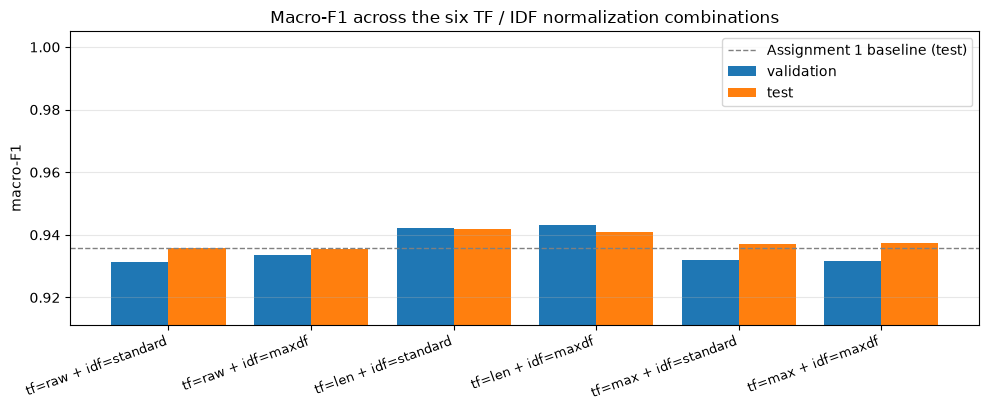

In [14]:
import matplotlib.pyplot as plt

names = [r["name"] for r in results]
val_scores = [r["val_macro_f1"] for r in results]
test_scores = [r["test_macro_f1"] for r in results]
x = np.arange(len(results))

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(x - 0.2, val_scores, 0.4, label="validation")
ax.bar(x + 0.2, test_scores, 0.4, label="test")
ax.axhline(baseline["test_macro_f1"], ls="--", c="gray", lw=1,
           label="Assignment 1 baseline (test)")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("macro-F1")
ax.set_ylim(min(min(val_scores), min(test_scores)) - 0.02, 1.005)
ax.set_title("Macro-F1 across the six TF / IDF normalization combinations")
ax.legend(); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

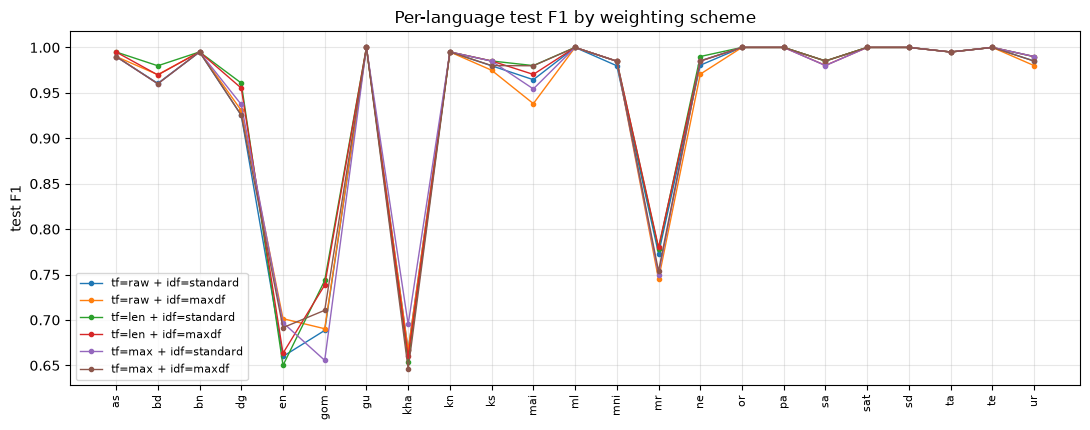

In [15]:
# per-language test F1 for every combination - where do the schemes actually differ?
fig, ax = plt.subplots(figsize=(11, 4.4))
for r in results:
    ax.plot(range(len(LABELS)), r["per_class_f1"], marker="o", ms=3, lw=1, label=r["name"])
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=90, fontsize=8)
ax.set_ylabel("test F1"); ax.set_title("Per-language test F1 by weighting scheme")
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [16]:
# which languages are most sensitive to the choice of weighting?
per_class = np.vstack([r["per_class_f1"] for r in results])
spread = per_class.max(axis=0) - per_class.min(axis=0)
order = np.argsort(-spread)
print("%-12s %8s %8s %8s" % ("language", "min F1", "max F1", "spread"))
print("-" * 40)
for i in order[:10]:
    print("%-12s %8.4f %8.4f %8.4f" % (LABELS[i], per_class[:, i].min(),
                                       per_class[:, i].max(), spread[i]))

language       min F1   max F1   spread
----------------------------------------
gom            0.6556   0.7435   0.0879
en             0.6500   0.7014   0.0514
kha            0.6458   0.6952   0.0494
mai            0.9381   0.9800   0.0419
dg             0.9254   0.9608   0.0354
mr             0.7449   0.7800   0.0351
bd             0.9600   0.9798   0.0198
ne             0.9706   0.9900   0.0194
ks             0.9749   0.9851   0.0102
ur             0.9800   0.9900   0.0100


In [17]:
with io.open(os.path.join(DATA_DIR, "assignment2_results.json"), "w", encoding="utf-8") as f:
    json.dump([{k: (v.tolist() if isinstance(v, np.ndarray) else v)
                for k, v in r.items()} for r in results], f, ensure_ascii=False, indent=1)
print("results saved -> " + os.path.join(DATA_DIR, "assignment2_results.json"))

results saved -> data\assignment2_results.json
